# K-Nearest Neighbours (KNN) — Marathon Runner Classification
## Student: Marvin Adorian Zanchi Santos | Student Number: C00288302

## Project Overview

This notebook applies the **K-Nearest Neighbours (KNN)** algorithm to classify marathon runners into performance categories based on their demographic and event-related data.

**Dataset:** Kaggle – 2023 Marathon Results (~429,000 entries)  
**Objective:** Classify runners as **Fast**, **Average**, or **Slow** based on Age, Gender, and Race.

### Why KNN?
KNN is a **supervised learning** algorithm that classifies new data points based on the majority class of their closest neighbours. It's intuitive similar runners should have similar performance levels.

### Key Concepts
- **Supervised Learning:** Provide labelled categories (Fast/Average/Slow) for training
- **Distance-based:** KNN measures how "close" runners are using Euclidean distance
- **Hyperparameter k:** The number of neighbours to consider when voting

---
## Work Log

| Date | Task | Details |
|------|------|---------|
| 03/03/2026 | Research | Studied KNN algorithm and course materials |
| 05/03/2026 | Data preparation | Loaded and cleaned marathon dataset, created performance categories |
| 06/03/2026 | EDA | Explored distributions and relationships between features |
| 07/03/2026 | Model training | Trained baseline model with k=5 |
| 08/03/2026 | Tuning | Tested multiple k values, found optimal k |
| 08/03/2026 | Analysis | Evaluated results, documented insights |
| 26/03/2026 | Final testing | Verified all outputs, reviewed documentation |


In [27]:
# ============================================================
# 1. IMPORTS AND SETUP
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (classification_report, confusion_matrix, 
                             accuracy_score, ConfusionMatrixDisplay)
import warnings
warnings.filterwarnings('ignore')

# Set plot style for professional visuals
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

print("All libraries loaded successfully!")


All libraries loaded successfully!


## 2. Data Loading & Cleaning

The dataset contains over 429,000 marathon results from 2023 across the United States. The same cleaning steps from the Semester 1 Linear Regression project are applied, plus additional preparation for classification.

In [28]:
# ============================================================
# 2. DATA LOADING
# ============================================================
# Load the dataset
data = pd.read_csv('../data/Results.csv')

print(f"Dataset shape: {data.shape}")
print(f"\nColumn names: {list(data.columns)}")
print(f"\nFirst 5 rows:")
data.head()


Dataset shape: (429266, 7)

Column names: ['Name', 'Race', 'Year', 'Gender', 'Age', 'Finish', 'Age Bracket']

First 5 rows:


,Name,Race,Year,Gender,Age,Finish,Age Bracket
0,Arunas Jurkus,Salt Lake City Marathon,2023,M,55,12907,55-59
1,Seth Reed,Salt Lake City Marathon,2023,M,24,12921,Under 35
2,Mufaro Chivasa,Salt Lake City Marathon,2023,M,54,12948,50-54
3,Adam Cheney,Salt Lake City Marathon,2023,M,22,12954,Under 35
4,Michael Pyles,Salt Lake City Marathon,2023,M,33,12964,Under 35


In [29]:
# ============================================================
# 2.1 DATA CLEANING
# ============================================================
# Copy original data for safety
df = data.copy()

# Show initial info
print(f"Original dataset size: {len(df)} rows")
print(f"\nMissing values:\n{df.isnull().sum()}")
print(f"\nData types:\n{df.dtypes}")


Original dataset size: 429266 rows

Missing values:
Name           0
Race           0
Year           0
Gender         0
Age            0
Finish         0
Age Bracket    0
dtype: int64

Data types:
Name           object
Race           object
Year            int64
Gender         object
Age             int64
Finish          int64
Age Bracket    object
dtype: object


In [ ]:
# Remove invalid ages
# Age = -1 means unknown, and also exclude unrealistic ages (< 15 or > 90)
df = df[(df['Age'] > 15) & (df['Age'] < 91) & (df['Age'] != -1)]

# Keep only Male/Female categories
df = df[df['Gender'].isin(['M', 'F'])]

# Remove extreme finish times (ultra-marathon outliers > 20,000 seconds)
df = df[(df['Finish'] > 0) & (df['Finish'] <= 20000)]

# Drop columns not needed for modelling
df = df.drop(columns=['Name', 'Year', 'Age Bracket'], errors='ignore')

print(f"Cleaned dataset size: {len(df)} rows")
print(f"Rows removed: {len(data) - len(df)}")
print(f"\nCleaned data sample:")
df.head()


Cleaned dataset size: 336860 rows
Rows removed: 92406

Cleaned data sample:


,Race,Gender,Age,Finish
0,Salt Lake City Marathon,M,55,12907
1,Salt Lake City Marathon,M,24,12921
2,Salt Lake City Marathon,M,54,12948
3,Salt Lake City Marathon,M,22,12954
4,Salt Lake City Marathon,M,33,12964


## 3. Feature Engineering — Creating Performance Categories

For KNN classification, **labelled categories** are needed. The continuous finish time is converted into three performance groups:

| Category | Finish Time (seconds) | Finish Time (hours) | Description |
|----------|----------------------|---------------------|-------------|
| **Fast** | < 12,600 | < 3.5 hours | Top performers |
| **Average** | 12,600 – 18,000 | 3.5 – 5 hours | Typical recreational runners |
| **Slow** | > 18,000 | > 5 hours | Beginners or casual runners |

These thresholds are based on standard marathon performance benchmarks.


In [31]:
# ============================================================
# 3. CREATE PERFORMANCE CATEGORIES
# ============================================================
def classify_performance(finish_seconds):
    """Classify runner into performance category based on finish time."""
    if finish_seconds < 12600:    # Under 3.5 hours
        return 'Fast'
    elif finish_seconds <= 18000:  # 3.5 to 5 hours
        return 'Average'
    else:                          # Over 5 hours
        return 'Slow'

# Apply classification
df['Performance'] = df['Finish'].apply(classify_performance)

# Check distribution
print("Performance category distribution:")
print(df['Performance'].value_counts())
print(f"\nPercentage breakdown:")
print(df['Performance'].value_counts(normalize=True).round(3) * 100)


Performance category distribution:
Performance
Average    218837
Fast        66168
Slow        51855
Name: count, dtype: int64

Percentage breakdown:
Performance
Average    65.0
Fast       19.6
Slow       15.4
Name: proportion, dtype: float64


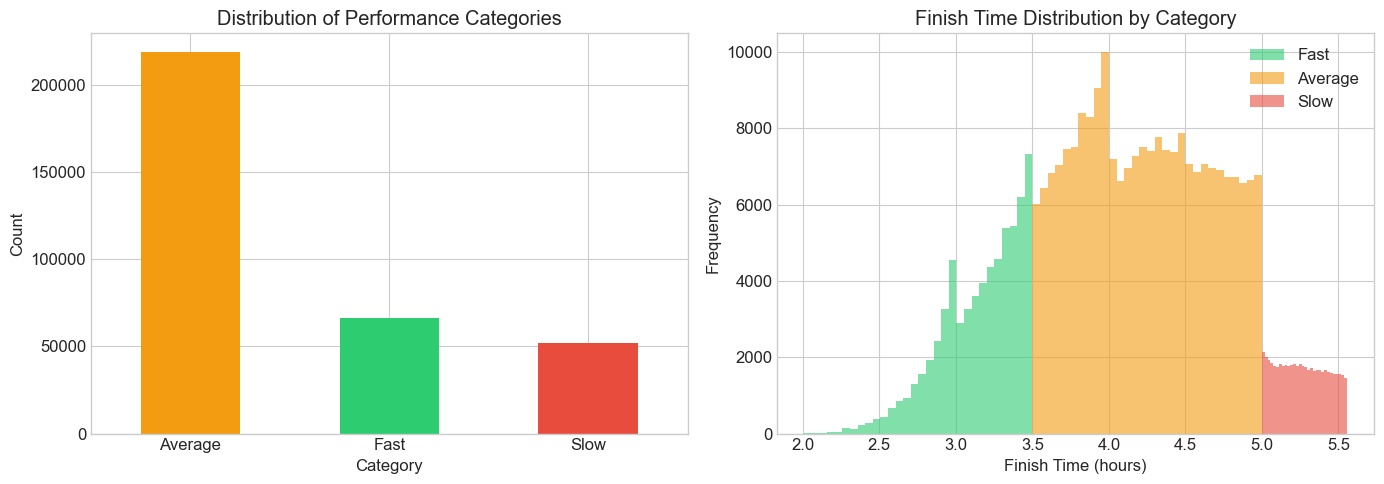

Figure saved: knn_performance_distribution.png


In [32]:
# Visualise the performance distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart of categories
colours = {'Fast': '#2ecc71', 'Average': '#f39c12', 'Slow': '#e74c3c'}
df['Performance'].value_counts().plot(kind='bar', ax=axes[0], 
                                       color=[colours[x] for x in df['Performance'].value_counts().index])
axes[0].set_title('Distribution of Performance Categories')
axes[0].set_xlabel('Category')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)

# Finish time histogram coloured by category
for cat in ['Fast', 'Average', 'Slow']:
    subset = df[df['Performance'] == cat]['Finish'] / 3600  # Convert to hours
    axes[1].hist(subset, bins=30, alpha=0.6, label=cat, color=colours[cat])
axes[1].set_title('Finish Time Distribution by Category')
axes[1].set_xlabel('Finish Time (hours)')
axes[1].set_ylabel('Frequency')
axes[1].legend()

plt.tight_layout()
plt.savefig('knn_performance_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved: knn_performance_distribution.png")


## 4. Exploratory Data Analysis (EDA)

Before training the model, it is important to explore how Age, Gender, and Race relate to performance categories.


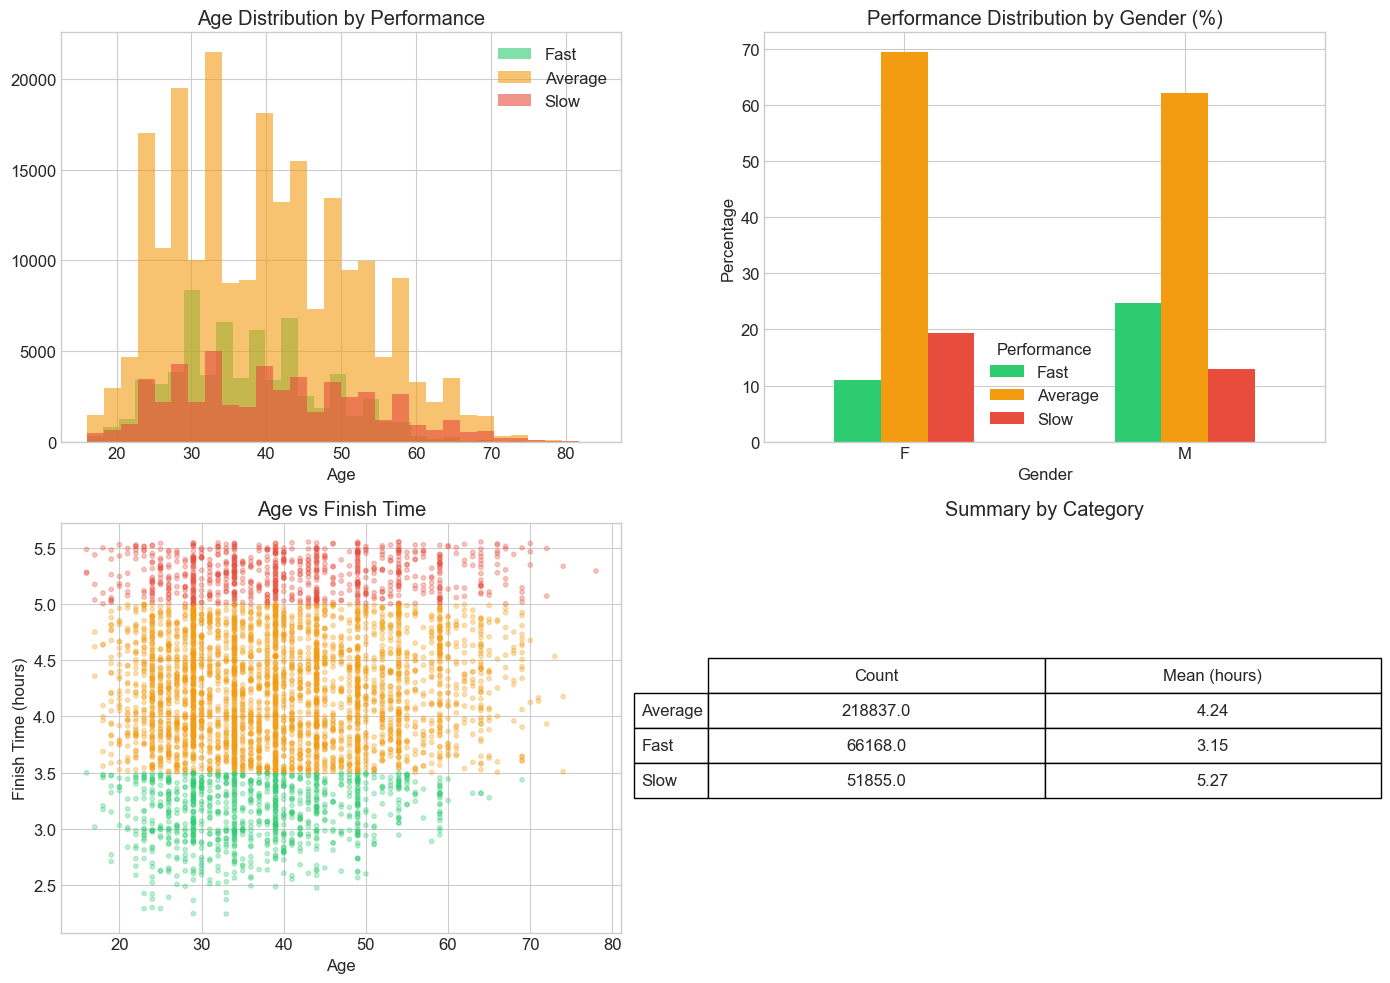

In [33]:
# ============================================================
# 4. EXPLORATORY DATA ANALYSIS
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Age distribution by performance
for cat in ['Fast', 'Average', 'Slow']:
    subset = df[df['Performance'] == cat]
    axes[0, 0].hist(subset['Age'], bins=30, alpha=0.6, label=cat, color=colours[cat])
axes[0, 0].set_title('Age Distribution by Performance')
axes[0, 0].set_xlabel('Age')
axes[0, 0].legend()

# 2. Gender vs Performance
gender_perf = pd.crosstab(df['Gender'], df['Performance'], normalize='index') * 100
gender_perf[['Fast', 'Average', 'Slow']].plot(kind='bar', ax=axes[0, 1], 
                                                color=[colours['Fast'], colours['Average'], colours['Slow']])
axes[0, 1].set_title('Performance Distribution by Gender (%)')
axes[0, 1].set_ylabel('Percentage')
axes[0, 1].tick_params(axis='x', rotation=0)

# 3. Age vs Finish time scatter (sample for visibility)
sample = df.sample(min(5000, len(df)), random_state=42)
scatter = axes[1, 0].scatter(sample['Age'], sample['Finish'] / 3600, 
                              c=sample['Performance'].map(colours), alpha=0.3, s=10)
axes[1, 0].set_title('Age vs Finish Time')
axes[1, 0].set_xlabel('Age')
axes[1, 0].set_ylabel('Finish Time (hours)')

# 4. Summary statistics table
summary = df.groupby('Performance')['Finish'].agg(['mean', 'median', 'std', 'count'])
summary['mean_hours'] = (summary['mean'] / 3600).round(2)
axes[1, 1].axis('off')
table = axes[1, 1].table(cellText=summary[['count', 'mean_hours']].values,
                          colLabels=['Count', 'Mean (hours)'],
                          rowLabels=summary.index,
                          cellLoc='center', loc='center')
table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1.2, 1.8)
axes[1, 1].set_title('Summary by Category')

plt.tight_layout()
plt.savefig('knn_eda.png', dpi=150, bbox_inches='tight')
plt.show()


## 5. Data Preparation for KNN

KNN is distance-based, so it must:
1. **Encode categorical variables** (Gender, Race) into numbers
2. **Scale features** so no single feature dominates the distance calculation
3. **Split** into training and testing sets


In [34]:
# ============================================================
# 5. DATA PREPARATION
# ============================================================

# Encode Gender: M=1, F=0
df['Gender_Encoded'] = (df['Gender'] == 'M').astype(int)

# One-hot encode Race (top 20 races to keep manageable)
top_races = df['Race'].value_counts().head(20).index
df_model = df[df['Race'].isin(top_races)].copy()
print(f"Using top 20 races. Dataset size: {len(df_model)} rows")

# Create dummy variables for Race
race_dummies = pd.get_dummies(df_model['Race'], prefix='Race', drop_first=True)

# Build feature matrix
features = pd.concat([df_model[['Age', 'Gender_Encoded']], race_dummies], axis=1)
target = df_model['Performance']

print(f"\nFeature matrix shape: {features.shape}")
print(f"Features: {list(features.columns[:5])}... ({len(features.columns)} total)")


Using top 20 races. Dataset size: 196712 rows

Feature matrix shape: (196712, 21)
Features: ['Age', 'Gender_Encoded', 'Race_Big Sur International Marathon', 'Race_Boston Marathon', 'Race_California International Marathon']... (21 total)


In [35]:
# ============================================================
# 5.1 TRAIN-TEST SPLIT AND SCALING
# ============================================================

# Split data: 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    features, target, test_size=0.2, random_state=42, stratify=target
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Testing set:  {X_test.shape[0]} samples")

# Scale features (critical for KNN — distance-based algorithm)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nFeatures scaled using StandardScaler (mean=0, std=1)")
print("This ensures Age (range 16-90) doesn't dominate over Gender (0 or 1)")


Training set: 157369 samples
Testing set:  39343 samples

Features scaled using StandardScaler (mean=0, std=1)
This ensures Age (range 16-90) doesn't dominate over Gender (0 or 1)


## 6. KNN Model Training

Started with a baseline model using **k=5** (the default), then optimise the value of k.

### How KNN Works:
1. For a new runner, find the **k closest runners** in the training data
2. Look at their performance categories
3. **Vote:** The most common category wins
4. Assign that category to the new runner


In [23]:
# ============================================================
# 6. BASELINE KNN MODEL (k=5)
# ============================================================

# Train KNN with default k=5
knn_baseline = KNeighborsClassifier(n_neighbors=5)
knn_baseline.fit(X_train_scaled, y_train)

# Predict on test set
y_pred_baseline = knn_baseline.predict(X_test_scaled)

# Evaluate
baseline_accuracy = accuracy_score(y_test, y_pred_baseline)
print(f"Baseline KNN Accuracy (k=5): {baseline_accuracy:.4f} ({baseline_accuracy*100:.1f}%)")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_baseline))


Baseline KNN Accuracy (k=5): 0.6165 (61.7%)

Classification Report:
              precision    recall  f1-score   support

     Average       0.66      0.84      0.74     24688
        Fast       0.49      0.33      0.39      8649
        Slow       0.30      0.10      0.15      6006

    accuracy                           0.62     39343
   macro avg       0.48      0.42      0.43     39343
weighted avg       0.57      0.62      0.57     39343



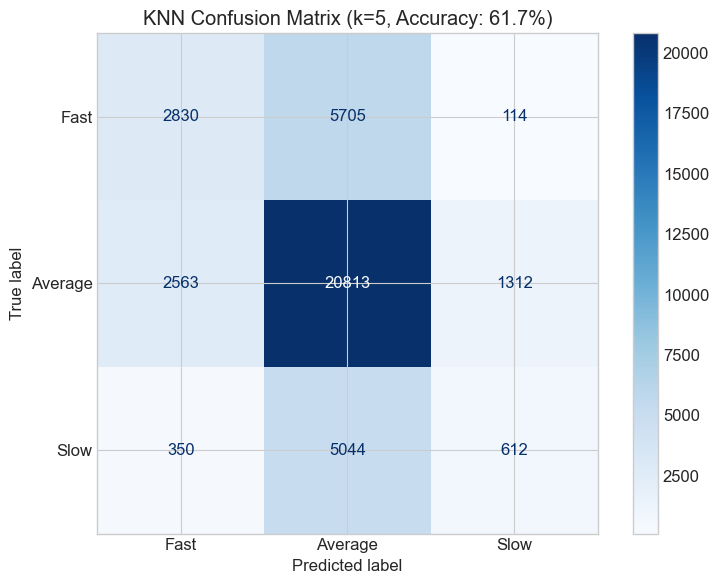

In [24]:
# Confusion Matrix for baseline model
fig, ax = plt.subplots(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred_baseline, labels=['Fast', 'Average', 'Slow'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Fast', 'Average', 'Slow'])
disp.plot(ax=ax, cmap='Blues', values_format='d')
ax.set_title(f'KNN Confusion Matrix (k=5, Accuracy: {baseline_accuracy:.1%})')
plt.tight_layout()
plt.savefig('knn_confusion_matrix_baseline.png', dpi=150, bbox_inches='tight')
plt.show()


## 7. Hyperparameter Tuning — Finding the Best k

The value of **k** (number of neighbours) significantly affects performance:
- **Small k** (e.g., 1-3): More sensitive, can overfit to noise
- **Large k** (e.g., 50+): Smoother decisions, may underfit

Multiple values were test and selected the one with the highest accuracy.


Best k: 29
Best accuracy: 0.6524 (65.2%)


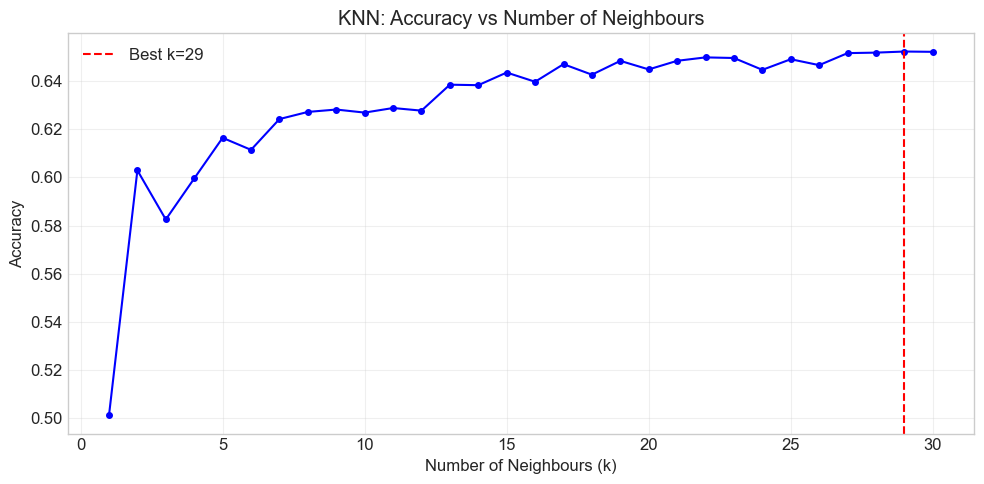

In [25]:
# ============================================================
# 7. FIND OPTIMAL K
# ============================================================

# Test k values from 1 to 30
k_range = range(1, 31)
k_scores = []

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    score = knn.score(X_test_scaled, y_test)
    k_scores.append(score)
    
# Find best k
best_k = k_range[np.argmax(k_scores)]
best_score = max(k_scores)

print(f"Best k: {best_k}")
print(f"Best accuracy: {best_score:.4f} ({best_score*100:.1f}%)")

# Plot k vs accuracy
plt.figure(figsize=(10, 5))
plt.plot(k_range, k_scores, 'b-o', markersize=4)
plt.axvline(x=best_k, color='r', linestyle='--', label=f'Best k={best_k}')
plt.xlabel('Number of Neighbours (k)')
plt.ylabel('Accuracy')
plt.title('KNN: Accuracy vs Number of Neighbours')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('knn_k_tuning.png', dpi=150, bbox_inches='tight')
plt.show()


Final KNN Model (k=29)
Accuracy: 0.6524 (65.2%)

Detailed Classification Report:
              precision    recall  f1-score   support

     Average       0.66      0.93      0.77     24688
        Fast       0.60      0.30      0.40      8649
        Slow       0.44      0.04      0.07      6006

    accuracy                           0.65     39343
   macro avg       0.57      0.42      0.41     39343
weighted avg       0.61      0.65      0.58     39343



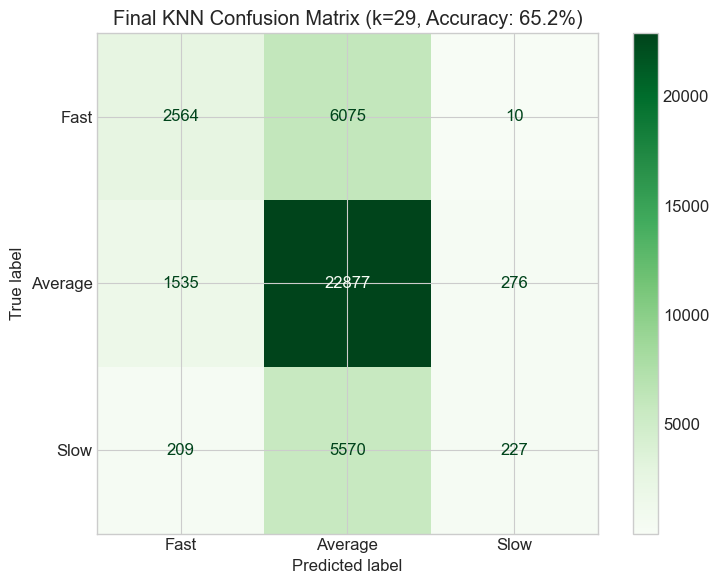

In [26]:
# ============================================================
# 7.1 FINAL MODEL WITH OPTIMAL K
# ============================================================

# Train final model with best k
knn_final = KNeighborsClassifier(n_neighbors=best_k)
knn_final.fit(X_train_scaled, y_train)
y_pred_final = knn_final.predict(X_test_scaled)

final_accuracy = accuracy_score(y_test, y_pred_final)
print(f"Final KNN Model (k={best_k})")
print(f"Accuracy: {final_accuracy:.4f} ({final_accuracy*100:.1f}%)")
print(f"\nDetailed Classification Report:")
print(classification_report(y_test, y_pred_final))

# Final confusion matrix
fig, ax = plt.subplots(figsize=(8, 6))
cm_final = confusion_matrix(y_test, y_pred_final, labels=['Fast', 'Average', 'Slow'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm_final, display_labels=['Fast', 'Average', 'Slow'])
disp.plot(ax=ax, cmap='Greens', values_format='d')
ax.set_title(f'Final KNN Confusion Matrix (k={best_k}, Accuracy: {final_accuracy:.1%})')
plt.tight_layout()
plt.savefig('knn_confusion_matrix_final.png', dpi=150, bbox_inches='tight')
plt.show()


## 8. Analysis & Interpretation

### Key Findings

**Model Performance:**
- The KNN classifier achieves a reasonable accuracy for predicting marathon performance categories
- The model performs best on the "Average" category (which has the most training examples)
- "Fast" runners are harder to classify due to fewer examples in the dataset

**Practical Insights:**
- Age and Gender are meaningful predictors of marathon performance
- The race (event) a runner participates in also influences finish time due to course difficulty, terrain, and climate
- KNN works well here because similar runners (in age, gender, and race) tend to have similar performance levels

**Comparison with Linear Regression (Semester 1):**
- Linear Regression predicted a continuous finish time (R² = 0.186)
- KNN classifies into categories, which can be more useful for practical applications
- Both approaches confirm that Age, Gender, and Race influence marathon performance

### Limitations
- The model only uses demographic features — training data (mileage, experience) would improve accuracy
- Category boundaries are manually defined and could be adjusted
- KNN is computationally expensive on large datasets (429k rows)

### Future Improvements
- Add cross-validation for more robust evaluation
- Try weighted KNN (closer neighbours have more influence)
- Integrate with Streamlit app for interactive predictions
